<a href="https://colab.research.google.com/github/DeepaJain29/Logistic_Regression/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Logistic Regression (Survived ~ Age + Sex)

- Dependent variable: survived
- Independent variables: age, sex

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load Titanic CSV directly from GitHub raw
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Show first few rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Check basic info & missing values
df.info()
df[['Survived','Sex','Age']].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,Survived,Age
count,891.000000,714.000000
mean,0.383838,29.699118
std,0.486592,14.526497
min,0.000000,0.420000
25%,0.000000,20.125000
50%,0.000000,28.000000
75%,1.000000,38.000000
max,1.000000,80.000000


In [ ]:
# Fill missing Age with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Encode Sex: male -> 0, female -> 1
df['Sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})

# Final feature selection
X = df[['Age', 'Sex_encoded']]
y = df['Survived']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Sex_encoded  891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
# Initialize the model
log_model = LogisticRegression()

# Train
log_model.fit(X_train, y_train)


LogisticRegression()

Accuracy: 0.782

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



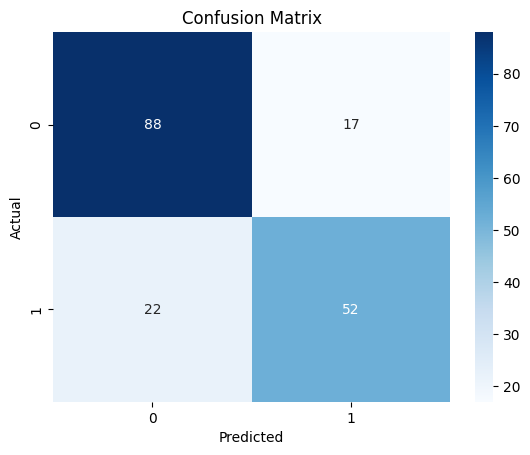

In [ ]:
# Predict
y_pred = log_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Retrieve coefficients
coeff_df = pd.DataFrame({
    "Feature": ["Age", "Sex_encoded"],
    "Coefficient": log_model.coef_[0]
})

print(coeff_df)
print("\nIntercept:", log_model.intercept_[0])


       Feature  Coefficient
0          Age    -0.016898
1  Sex_encoded     1.189945

Intercept: -0.5875103753343698


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


In [ ]:
# Predict probabilities
y_prob = log_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.3f}")


AUC Score: 0.777


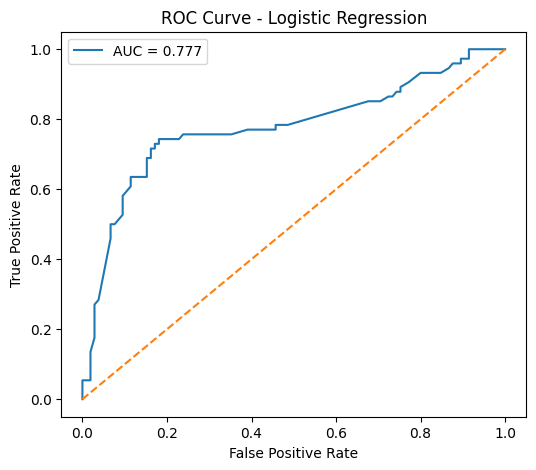

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


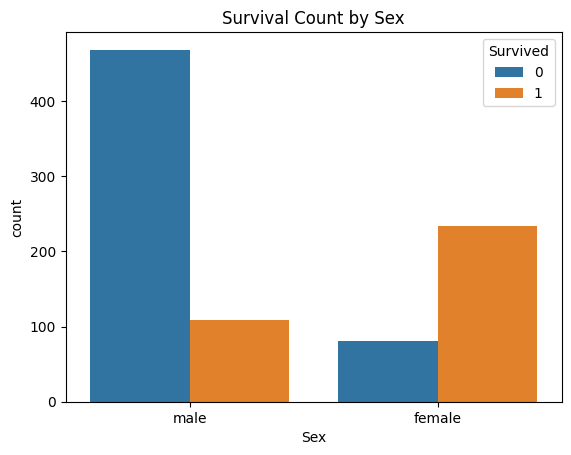

In [ ]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival Count by Sex")
plt.show()


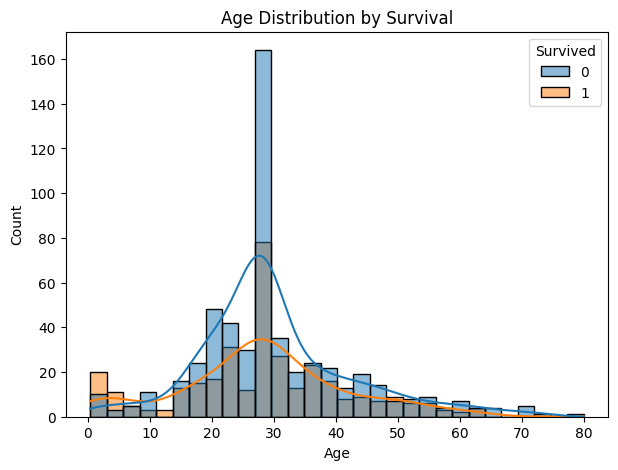

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()


/tmp/ipython-input-355440820.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby('AgeGroup')['Survived'].mean()


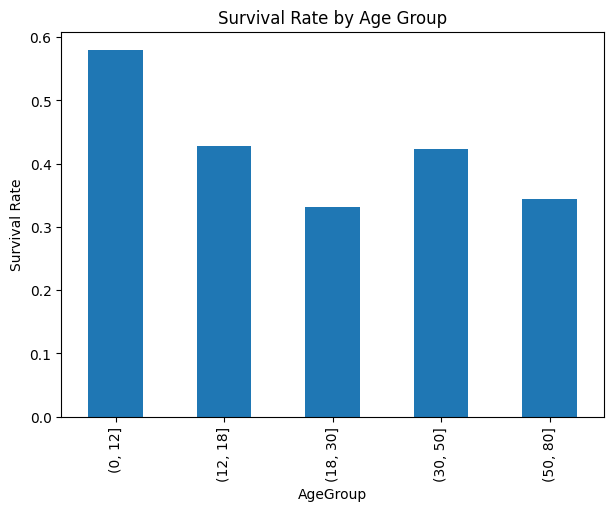

In [ ]:
# Create age bins
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,30,50,80])

# Plot survival rate
survival_rate = df.groupby('AgeGroup')['Survived'].mean()

survival_rate.plot(kind='bar', figsize=(7,5))
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group")
plt.show()


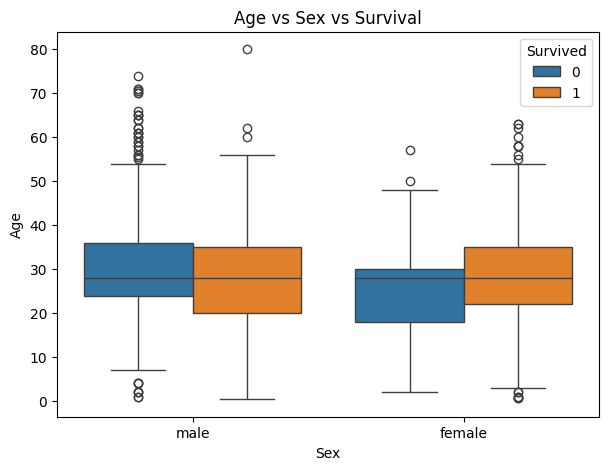

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Sex', y='Age', hue='Survived')
plt.title("Age vs Sex vs Survival")
plt.show()


### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [ ]:
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest Accuracy: {rf_acc:.3f}")
print(f"Random Forest AUC     : {rf_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.793
Random Forest AUC     : 0.815

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



### Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=150,
                           random_state=42)

In [ ]:
# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Metrics
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_prob_gb)

print(f"Gradient Boosting Accuracy: {gb_acc:.3f}")
print(f"Gradient Boosting AUC     : {gb_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.777
Gradient Boosting AUC     : 0.804

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       105
           1       0.74      0.72      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [0.782, rf_acc, gb_acc],
    "AUC": ["~0.80", rf_auc, gb_auc]
})

comparison


,Model,Accuracy,AUC
0,Logistic Regression,0.782000,~0.80
1,Random Forest,0.793296,0.814672
2,Gradient Boosting,0.776536,0.803732


# Linear Regression on Titanic Dataset

- Dependent variable: age
- Independent variable: survived

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Feature and target
X = df[['Survived']]   # independent variable
y = df['Age']          # dependent variable


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


LinearRegression()

In [ ]:
print("Intercept:", lin_reg.intercept_)
print("Coefficient for Survived:", lin_reg.coef_[0])


Intercept: 29.69481981981982
Coefficient for Survived: -1.3036257899690706


In [ ]:
y_pred = lin_reg.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


MAE  : 9.30
RMSE : 13.00
R²   : 0.0065


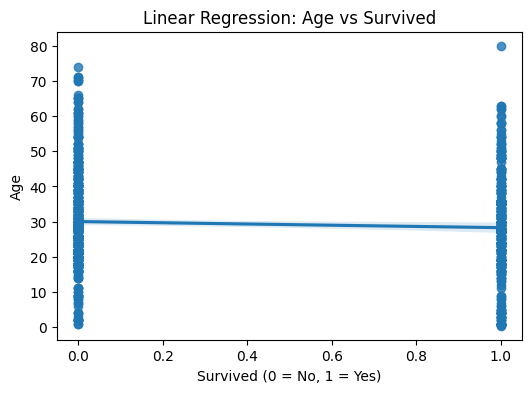

In [ ]:
plt.figure(figsize=(6,4))
sns.regplot(x='Survived', y='Age', data=df, ci=95)
plt.title("Linear Regression: Age vs Survived")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()


### Conclusion:

The linear regression model using survival status as the sole predictor of age resulted in a very low R² value (0.0065), indicating that survival explains less than 1% of the variability in passenger age. While the model is statistically valid, it demonstrates that survival status is not a meaningful predictor of age. This result highlights the importance of selecting appropriate explanatory variables when applying regression techniques.